# Validación externa: clustering vs. polígonos de desmonte (Chaco Seco)

Cruza las 6 tipologías de `land2vec` v2 (`scripts/clustering/tune_clustering.py --select`) contra los
polígonos de desmonte de Colección 13.0 (monitoreodesmonte.com.ar), ya procesados por
`scripts/datos/build_desmonte_labels.py` y `scripts/validacion/eval_desmonte.py`. Ver
`docs/v2/paper_metodologia.md` §5.8 para el detalle metodológico completo.

**Consume, no produce.** Este notebook solo lee lo que dejan los scripts; no recalcula el cruce
geométrico ni reajusta el clustering. Para las tablas/figuras de detalle (Tabla 2, Tabla 3,
F2-F4, análisis de errores) reconstruye la "mesa maestra" por píxel llamando directamente a las
funciones de `scripts/validacion/eval_desmonte.py` -- son joins sobre datos ya calculados, no geometría.

**Unidad de reporte: por zona, sin poolear.** `chaco_santiago_frontier` es el resultado
"Chaco Seco" (*headline*); `yungas` y `periurbano_cordoba` van marcadas *fuera de ecorregión* --
contraste de generalización del encoder/clustering, nunca evidencia sobre desmonte en el Chaco Seco.

**Prerrequisitos** (en este orden, en tu máquina, fuera de un contenedor sin geopandas/torch):

```bash
python scripts/clustering/assign_train_clusters.py --group all --max-constant-fraction 1.0 --out-tag _full
python scripts/datos/build_desmonte_labels.py           # las 3 zonas con polígonos
python scripts/validacion/eval_desmonte.py --n-boot 999       # bootstrap completo, más lento (--n-boot 200 para una pasada rápida)
```


In [1]:
# --- bootstrap: correr el notebook desde una copia local del repo, fuera del container ---
# No clona ni instala nada. Ubica la raíz del repo (la carpeta con setup.py),
# se para ahí y pone land2vec (src/) y scripts/ en el path. Da igual desde dónde arranque el kernel.
import os, sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "setup.py").is_file() and _root != _root.parent:
    _root = _root.parent
assert (_root / "setup.py").is_file(), \
    f"No encuentro la raíz del repo land2vec (setup.py) desde {Path.cwd()}"
os.chdir(_root)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
if str(_root / "scripts" / "validacion") not in sys.path:
    sys.path.insert(0, str(_root / "scripts" / "validacion"))
print("repo root:", _root)


repo root: /media/grosati/Elements1/PEN/Datasets_ML/land2vec


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eval_desmonte as ED  # Fase 3/4: label_reference, build_base, attach_cluster, gain_curve_oof, ...

DATA_DIR = Path("data")
CLUSTER_DIR = Path("models") / "v2" / "cluster_v2"

ZONES = ED.ZONES
FUERA_ECORREGION = ED.FUERA_ECORREGION
SUFFIXES = ED.SUFFIXES
NIVEL_LABELS = {
    "": "fina/HDBSCAN", "_parametric": "fina/GMM",
    "_medium": "media/HDBSCAN", "_medium_parametric": "media/GMM",
    "_coarse": "gruesa/HDBSCAN", "_coarse_parametric": "gruesa/GMM",
}

pd.set_option("display.float_format", lambda x: f"{x:.3f}")


## 1. Carga de los resultados de `eval_desmonte.py`

In [3]:
eval_rows = []
for suffix in SUFFIXES:
    path = CLUSTER_DIR / f"desmonte_eval{suffix}.csv"
    if not path.exists():
        print(f"falta {path} -- corré scripts/validacion/eval_desmonte.py")
        continue
    eval_rows.append(pd.read_csv(path))

eval_df = (
    pd.concat(eval_rows, ignore_index=True).drop_duplicates(subset=["zone", "suffix", "nivel"], keep="first")
    if eval_rows else pd.DataFrame()
)

lift_path = CLUSTER_DIR / "desmonte_lift_por_cluster.csv"
decil_path = CLUSTER_DIR / "desmonte_deteccion_por_decil.csv"
lift_df = pd.read_csv(lift_path) if lift_path.exists() else pd.DataFrame()
decil_df = pd.read_csv(decil_path) if decil_path.exists() else pd.DataFrame()

for _df in (eval_df, lift_df, decil_df):
    if "suffix" in _df.columns:
        _df["suffix"] = _df["suffix"].fillna("")  # pandas lee la corrida "fina" (suffix="") como NaN

summary_path = CLUSTER_DIR / "desmonte_eval_summary.json"
summary = json.loads(summary_path.read_text()) if summary_path.exists() else {}

print(f"{len(eval_df)} filas cargadas ({eval_df['zone'].nunique() if not eval_df.empty else 0} zonas)")
eval_df.head()


42 filas cargadas (3 zonas)


,zone,suffix,nivel,fuera_ecorregion,n,n_bloques,prevalencia,mcc_neg1_neg,mcc_neg1_neg_ci_lo,mcc_neg1_neg_ci_hi,...,mcc_tipificados,precision_tipificados,recall_tipificados,f1_tipificados,deteccion_poligonos,n_poligonos_ventana,pct_2anios_cluster,mediana_err_anio_pixel,sesgo_anio_pixel,pct_2anios_pixel
0,chaco_santiago_frontier,,r0,False,1424457,4510.000,0.260,0.399,0.387,0.412,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chaco_santiago_frontier,,r1,False,1424457,4510.000,0.260,0.360,0.347,0.373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chaco_santiago_frontier,,fina,False,1424457,4510.000,0.260,0.553,0.538,0.568,...,0.378,0.837,0.981,0.903,0.387,25469.000,0.739,1.000,1.000,0.742
3,chaco_santiago_frontier,,permutacion,False,1424457,NaN,NaN,0.001,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,yungas,,r0,True,20505,480.000,0.179,0.462,0.415,0.510,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Tabla 1 -- Validación externa contra polígonos de desmonte

Una instancia por zona (ninguna pooleada). Filas: las 6 corridas + `R0`/`R1` (líneas de base sobre
la secuencia cruda, sin clustering). La línea de permutación espacial no entra acá -- es la Δ que
se reporta en el texto junto al MCC real de cada corrida (ver celda de abajo).

In [4]:
TABLA1_COLS = [
    "nivel", "n", "n_bloques",
    "cobertura_positivo", "prevalencia",
    "gain_at_10", "auc_pr_oof", "u_ajustado",
    "mcc_neg1_neg", "mcc_neg1_neg_ci_lo", "mcc_neg1_neg_ci_hi",
    "mcc_tipificados",
    "precision_neg1_neg", "recall_neg1_neg",
    "mediana_err_anio_cluster", "sesgo_anio_cluster", "pct_2anios_cluster",
    "mediana_err_anio_pixel", "pct_2anios_pixel",
    "deteccion_poligonos", "n_poligonos_ventana",
]


def tabla1(zone: str) -> pd.DataFrame:
    "Fila por corrida real + R0 + R1 -- sin la línea de permutación."
    sub = eval_df[(eval_df["zone"] == zone) & (eval_df["nivel"] != "permutacion")].copy()
    cols = [c for c in TABLA1_COLS if c in sub.columns]
    return sub[cols].sort_values("mcc_neg1_neg", ascending=False).reset_index(drop=True)


def delta_permutacion(zone: str, suffix: str) -> float | None:
    "MCC real de la corrida menos el MCC de su línea de base de permutación espacial."
    real = eval_df[(eval_df["zone"] == zone) & (eval_df["suffix"] == suffix) & (eval_df["nivel"] != "permutacion")]
    perm = eval_df[(eval_df["zone"] == zone) & (eval_df["suffix"] == suffix) & (eval_df["nivel"] == "permutacion")]
    if real.empty or perm.empty:
        return None
    return float(real["mcc_neg1_neg"].iloc[0] - perm["mcc_neg1_neg"].iloc[0])


print("=== Chaco Seco (chaco_santiago_frontier) -- resultado headline ===")
tabla1("chaco_santiago_frontier")


=== Chaco Seco (chaco_santiago_frontier) -- resultado headline ===


,nivel,n,n_bloques,cobertura_positivo,prevalencia,gain_at_10,auc_pr_oof,u_ajustado,mcc_neg1_neg,mcc_neg1_neg_ci_lo,...,mcc_tipificados,precision_neg1_neg,recall_neg1_neg,mediana_err_anio_cluster,sesgo_anio_cluster,pct_2anios_cluster,mediana_err_anio_pixel,pct_2anios_pixel,deteccion_poligonos,n_poligonos_ventana
0,fina,1424457,4510.000,0.145,0.260,0.333,0.626,0.244,0.553,0.538,...,0.378,0.837,0.484,1.000,0.000,0.739,1.000,0.742,0.387,25469.000
1,parametric,1424457,4510.000,0.145,0.260,0.336,0.718,0.335,0.534,0.521,...,0.175,0.611,0.723,2.000,0.000,0.577,1.000,0.742,0.653,25469.000
2,medium_parametric,1424457,4510.000,0.145,0.260,0.335,0.727,0.360,0.514,0.498,...,0.087,0.533,0.830,2.000,-1.000,0.557,1.000,0.742,0.848,25469.000
3,coarse_parametric,1424457,4510.000,0.145,0.260,0.284,0.623,0.275,0.466,0.450,...,0.032,0.518,0.768,3.000,-2.000,0.432,1.000,0.742,0.793,25469.000
4,medium,1424457,4510.000,0.145,0.260,0.332,0.641,0.246,0.450,0.435,...,0.137,0.582,0.613,2.000,-1.000,0.530,1.000,0.742,0.559,25469.000
5,coarse,1424457,4510.000,0.145,0.260,0.292,0.615,0.226,0.415,0.400,...,0.210,0.567,0.567,6.000,-4.000,0.246,1.000,0.742,0.510,25469.000
6,r0,1424457,4510.000,NaN,0.260,NaN,NaN,NaN,0.399,0.387,...,NaN,0.873,0.254,1.000,1.000,NaN,NaN,NaN,NaN,NaN
7,r1,1424457,4510.000,NaN,0.260,NaN,NaN,NaN,0.360,0.347,...,NaN,0.887,0.203,1.000,1.000,NaN,NaN,NaN,NaN,NaN


### Fuera de ecorregión -- comparación de generalización

No es evidencia sobre desmonte en el Chaco Seco: `yungas` es in-sample para el encoder /
out-of-sample para el clustering (igual que Chaco); `periurbano_cordoba` es al revés. Sirven
para leer si el MCC/ganancia se sostiene fuera de donde se ajustó el clustering (`chaco↔córdoba`
es el único indicio disponible de sobreajuste del encoder, con potencia baja: n=80 polígonos).

In [5]:
for zone in FUERA_ECORREGION:
    print(f"=== {zone} (fuera de ecorregión) ===")
    display(tabla1(zone))


=== periurbano_cordoba (fuera de ecorregión) ===


,nivel,n,n_bloques,cobertura_positivo,prevalencia,gain_at_10,auc_pr_oof,u_ajustado,mcc_neg1_neg,mcc_neg1_neg_ci_lo,...,mcc_tipificados,precision_neg1_neg,recall_neg1_neg,mediana_err_anio_cluster,sesgo_anio_cluster,pct_2anios_cluster,mediana_err_anio_pixel,pct_2anios_pixel,deteccion_poligonos,n_poligonos_ventana
0,medium,20736,64.000,0.012,0.043,0.178,0.112,0.166,0.139,-0.071,...,0.083,0.123,0.315,1.000,-1.000,0.649,NaN,NaN,0.138,80.000
1,parametric,20736,64.000,0.012,0.043,0.207,0.073,0.174,0.137,-0.072,...,0.104,0.121,0.315,1.000,0.000,0.581,NaN,NaN,0.138,80.000
2,coarse,20736,64.000,0.012,0.043,0.033,0.040,0.115,0.133,-0.074,...,0.137,0.117,0.315,16.000,16.000,0.333,NaN,NaN,0.138,80.000
3,coarse_parametric,20736,64.000,0.012,0.043,0.041,0.044,0.086,0.092,0.007,...,0.002,0.062,0.689,1.000,1.000,0.726,NaN,NaN,0.700,80.000
4,medium_parametric,20736,64.000,0.012,0.043,0.183,0.119,0.201,0.089,0.002,...,0.099,0.062,0.680,1.000,1.000,0.733,NaN,NaN,0.700,80.000
5,r1,20736,64.000,NaN,0.043,NaN,NaN,NaN,-0.013,-0.028,...,NaN,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,r0,20736,64.000,NaN,0.043,NaN,NaN,NaN,-0.015,-0.030,...,NaN,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,fina,20736,64.000,0.012,0.043,0.108,0.078,0.105,-0.033,-0.064,...,-0.100,0.000,0.000,14.000,14.000,0.000,NaN,NaN,0.000,80.000


=== yungas (fuera de ecorregión) ===


,nivel,n,n_bloques,cobertura_positivo,prevalencia,gain_at_10,auc_pr_oof,u_ajustado,mcc_neg1_neg,mcc_neg1_neg_ci_lo,...,mcc_tipificados,precision_neg1_neg,recall_neg1_neg,mediana_err_anio_cluster,sesgo_anio_cluster,pct_2anios_cluster,mediana_err_anio_pixel,pct_2anios_pixel,deteccion_poligonos,n_poligonos_ventana
0,medium_parametric,20505,480.000,0.088,0.179,0.492,0.730,0.466,0.638,0.577,...,0.002,0.630,0.799,2.000,-1.000,0.618,1.000,0.751,0.858,1592.000
1,parametric,20505,480.000,0.088,0.179,0.496,0.691,0.385,0.605,0.552,...,0.159,0.675,0.676,1.000,0.000,0.720,1.000,0.751,0.810,1592.000
2,fina,20505,480.000,0.088,0.179,0.488,0.581,0.282,0.598,0.546,...,0.269,0.878,0.476,1.000,0.000,0.756,1.000,0.751,0.673,1592.000
3,coarse_parametric,20505,480.000,0.088,0.179,0.413,0.657,0.392,0.548,0.486,...,-0.103,0.598,0.671,3.000,-2.000,0.403,1.000,0.751,0.697,1592.000
4,medium,20505,480.000,0.088,0.179,0.464,0.579,0.290,0.523,0.466,...,0.066,0.650,0.557,2.000,-1.000,0.615,1.000,0.751,0.636,1592.000
5,coarse,20505,480.000,0.088,0.179,0.391,0.618,0.343,0.508,0.454,...,0.114,0.641,0.540,5.000,-5.000,0.263,1.000,0.751,0.622,1592.000
6,r0,20505,480.000,NaN,0.179,NaN,NaN,NaN,0.462,0.415,...,NaN,0.893,0.289,1.000,1.000,NaN,NaN,NaN,NaN,NaN
7,r1,20505,480.000,NaN,0.179,NaN,NaN,NaN,0.427,0.378,...,NaN,0.894,0.248,1.000,1.000,NaN,NaN,NaN,NaN,NaN


## 3. Selección externa de granularidad

In [6]:
for zone, info in summary.get("por_zona", {}).items():
    tag = "fuera de ecorregión" if info["fuera_ecorregion"] else "Chaco Seco"
    best = info["mejor_suffix_mcc_oof"]
    print(f"{zone} ({tag}): mejor corrida por MCC externo = {best!r} ({NIVEL_LABELS.get(best, '?')})")


chaco_santiago_frontier (Chaco Seco): mejor corrida por MCC externo = '' (fina/HDBSCAN)
yungas (fuera de ecorregión): mejor corrida por MCC externo = '_medium_parametric' (media/GMM)
periurbano_cordoba (fuera de ecorregión): mejor corrida por MCC externo = '_medium' (media/HDBSCAN)


Contraste con la selección **interna** (`docs/v2/v2_autoencoder_training.md` §7.2, criterio de
`select_winner()`: `stability_ari`/`prototype_fidelity`/`silhouette`/`spatial_coherence`,
recomendada `media/HDBSCAN`). Si la externa no coincide, es un hallazgo metodológico en sí mismo
-- no un error: compararía qué tan bien un criterio puramente interno anticipa el desempeño contra
un dato independiente.

In [7]:
interno = []
for suffix in SUFFIXES:
    p = CLUSTER_DIR / f"chosen{suffix}.json"
    if p.exists():
        cfg = json.loads(p.read_text())
        interno.append({
            "suffix": suffix, "nivel": NIVEL_LABELS[suffix],
            "silhouette": cfg["metrics"].get("silhouette_mean"),
            "prototype_fidelity": cfg["metrics"].get("prototype_fidelity"),
            "spatial_coherence": cfg["metrics"].get("spatial_coherence"),
        })
pd.DataFrame(interno)


,suffix,nivel,silhouette,prototype_fidelity,spatial_coherence
0,,fina/HDBSCAN,0.913,0.955,0.602
1,_parametric,fina/GMM,0.735,0.905,0.585
2,_medium,media/HDBSCAN,0.797,0.866,0.631
3,_medium_parametric,media/GMM,0.547,0.719,0.600
4,_coarse,gruesa/HDBSCAN,0.580,0.740,0.595
5,_coarse_parametric,gruesa/GMM,0.470,0.578,0.562


## 4. Reconstrucción de la mesa maestra (Chaco, las 6 corridas)

Para la Tabla 2, la Tabla 3 y las figuras F2-F4 hace falta la mesa píxel a píxel, no solo el
resumen escalar de `desmonte_eval*.csv`. Se arma una sola vez por corrida reutilizando
`build_base`/`attach_cluster` de `scripts/validacion/eval_desmonte.py` -- sin volver a tocar el shapefile ni
el cruce geométrico, que ya está resuelto en `data/desmonte/desmonte_px*`/`data/desmonte/desmonte_poly_px*`.

In [8]:
zone = "chaco_santiago_frontier"

px = ED.load_desmonte_px(zone, DATA_DIR)
poly_px = ED.load_desmonte_poly_px(zone, DATA_DIR)
coords_df = ED.load_coords(zone, DATA_DIR)
seqs_df = ED.load_seqs(zone, DATA_DIR)

baselines = ED.baseline_table(seqs_df)
baselines = baselines.merge(ED.reference_year(poly_px).rename("anio_ref"), left_on="ID", right_index=True, how="left")
grid = ED.G.ZoneGrid.from_coords(coords_df, zone)
weights_df = ED.compute_weights(seqs_df, grid)  # peso=1 en grillas completas; corrige el submuestreo de constantes en yungas
base = ED.build_base(px, coords_df, baselines, weights_df, tau=ED.TAU)

cluster_info = ED.load_cluster_info()
masters = {}
for suffix in SUFFIXES:
    clusters_df = ED.load_clusters(suffix, DATA_DIR)
    info = cluster_info.get(suffix, {})
    if info:
        masters[suffix] = ED.attach_cluster(base, zone, clusters_df, info)

best_suffix = summary.get("por_zona", {}).get(zone, {}).get("mejor_suffix_mcc_oof")
print("corrida ganadora (externa):", best_suffix, "--", NIVEL_LABELS.get(best_suffix))
master_best = masters[best_suffix]
len(master_best)


corrida ganadora (externa):  -- fina/HDBSCAN


1424457

## 5. Tabla 2 -- por proceso conceptual (corrida ganadora)

`tasa_desmonte` no usa ninguna regla semántica: es la fracción real de píxeles `positivo` dentro
de cada proceso (asociación pura). La precisión "de facto" de cada proceso frente al MCC de la
Tabla 1 se lee directo de esta tasa para los dos procesos que arma la regla semántica
(`deforestacion`, `degradacion_forestal`): ahí `tasa_desmonte` **es** la precisión.

In [9]:
def tabla2_por_proceso(master: pd.DataFrame) -> pd.DataFrame:
    sub = master[master["referencia"].isin(["positivo", "negativo_limpio"])]
    p_global = (sub["referencia"] == "positivo").mean()

    g = sub.groupby("proceso").agg(
        n=("proceso", "size"),
        tasa_desmonte=("referencia", lambda s: (s == "positivo").mean()),
        anio_cambio_mediano=("anio_cambio", "median"),
    )
    g["pct_area"] = g["n"] / g["n"].sum()
    g["lift"] = g["tasa_desmonte"] / p_global

    pos = sub[sub["referencia"] == "positivo"]
    g["anio_ref_mediano"] = pos.groupby("proceso")["anio_ref"].median()
    return g.sort_values("tasa_desmonte", ascending=False)


tabla2_por_proceso(master_best)


,n,tasa_desmonte,anio_cambio_mediano,pct_area,lift,anio_ref_mediano
proceso,,,,,,
deforestacion,57185,0.874,2005.000,0.072,3.356,2004.000
degradacion_forestal,62292,0.802,2007.000,0.079,3.082,2007.000
otro,59,0.763,2001.000,0.000,2.929,2003.000
expansion_agricola,2877,0.417,2001.000,0.004,1.603,2004.000
dinamica_hidrica,873,0.213,2005.000,0.001,0.818,2010.000
sin_info,665080,0.157,NaN,0.839,0.604,2011.000
regeneracion_bosque,4324,0.115,2016.000,0.005,0.443,2006.000
urbanizacion,409,0.002,2013.000,0.001,0.009,2001.000
oscilante,1,0.000,2010.000,0.000,0.000,NaN


## 6. Tabla 3 -- controles (pre-2000 / post-2022)

Los controles no entran a la Tabla 1: acá se lee qué proceso les asignó la tipología. La
predicción correcta es que `control_pre` (ya desmontado en 2000) caiga en `otro`/estable o
`expansion_agricola`, **no** en `deforestacion`; y que `control_post` (bosque verificado en pie
hasta 2022) caiga en `otro`/`regeneracion_bosque`, no en ningún proceso de pérdida.

In [10]:
def tabla3_controles(master: pd.DataFrame) -> pd.DataFrame:
    sub = master[master["referencia"].isin(["positivo", "control_pre", "control_post", "negativo_limpio"])]
    return pd.crosstab(sub["referencia"], sub["proceso"], normalize="index")


tabla3_controles(master_best)


proceso,deforestacion,degradacion_forestal,dinamica_hidrica,expansion_agricola,oscilante,otro,perdida_vegetacion,regeneracion_bosque,sin_info,urbanizacion
referencia,,,,,,,,,,
control_post,0.021,0.026,0.001,0.000,0.000,0.000,0.000,0.002,0.950,0.000
control_pre,0.046,0.016,0.000,0.031,0.000,0.000,0.000,0.004,0.900,0.002
negativo_limpio,0.012,0.021,0.001,0.003,0.000,0.000,0.000,0.007,0.955,0.001
positivo,0.242,0.242,0.001,0.006,0.000,0.000,0.000,0.002,0.507,0.000


## 7. Figuras

/media/grosati/Elements1/PEN/Datasets_ML/land2vec/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


/media/grosati/Elements1/PEN/Datasets_ML/land2vec/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


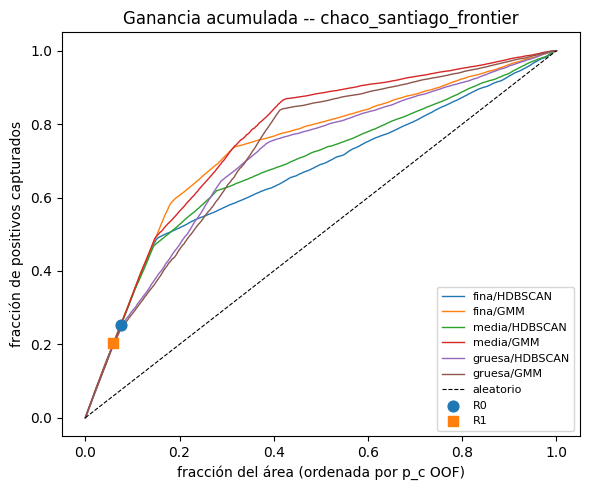

In [11]:
# F2 -- curvas de ganancia acumulada de las 6 corridas, con R0/R1 como puntos
fig, ax = plt.subplots(figsize=(6, 5))
for suffix, master in masters.items():
    ordered, gain10, _ = ED.gain_curve_oof(master)
    if not ordered.empty:
        ax.plot(ordered["area_cum"], ordered["pos_cum"], label=NIVEL_LABELS[suffix], linewidth=1)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="aleatorio")

for rule, marker in [("r0", "o"), ("r1", "s")]:
    conf = ED.baseline_confusion(base, rule)
    if conf["n"]:
        area = (conf["vp"] + conf["fp"]) / conf["n"]
        ax.scatter([area], [conf["recall"]], marker=marker, s=60, zorder=5, label=rule.upper())

ax.set_xlabel("fracción del área (ordenada por p_c OOF)")
ax.set_ylabel("fracción de positivos capturados")
ax.set_title(f"Ganancia acumulada -- {zone}")
ax.legend(fontsize=8)
fig.tight_layout()


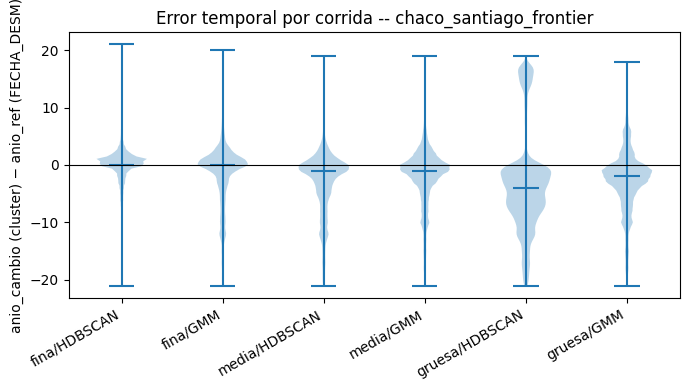

In [12]:
# F3 -- error temporal por corrida (anio_cambio del cluster vs. anio_ref del pixel)
fig, ax = plt.subplots(figsize=(7, 4))
data, labels = [], []
for suffix, master in masters.items():
    sub = master[master["referencia"] == "positivo"].dropna(subset=["anio_ref"])
    err = (sub["anio_cambio"] - sub["anio_ref"]).dropna()
    if len(err):
        data.append(err.to_numpy())
        labels.append(NIVEL_LABELS[suffix])

if data:
    ax.violinplot(data, showmedians=True)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=30, ha="right")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("anio_cambio (cluster) − anio_ref (FECHA_DESM)")
ax.set_title(f"Error temporal por corrida -- {zone}")
fig.tight_layout()


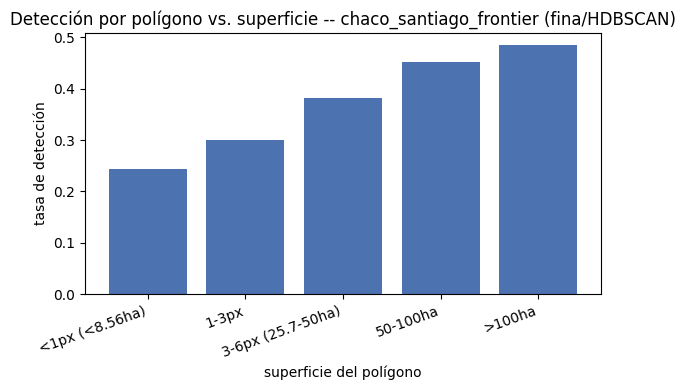

In [13]:
# F4 -- detección por polígono vs. superficie, corrida ganadora
fig, ax = plt.subplots(figsize=(6, 4))
sub = decil_df[(decil_df["zone"] == zone) & (decil_df["suffix"] == (best_suffix or ""))]
if not sub.empty:
    ax.bar(sub["decil"].astype(str), sub["tasa_deteccion"], color="#4C72B0")
    ax.set_ylabel("tasa de detección")
    ax.set_xlabel("superficie del polígono")
    ax.set_title(f"Detección por polígono vs. superficie -- {zone} ({NIVEL_LABELS.get(best_suffix, best_suffix)})")
    plt.xticks(rotation=20, ha="right")
fig.tight_layout()


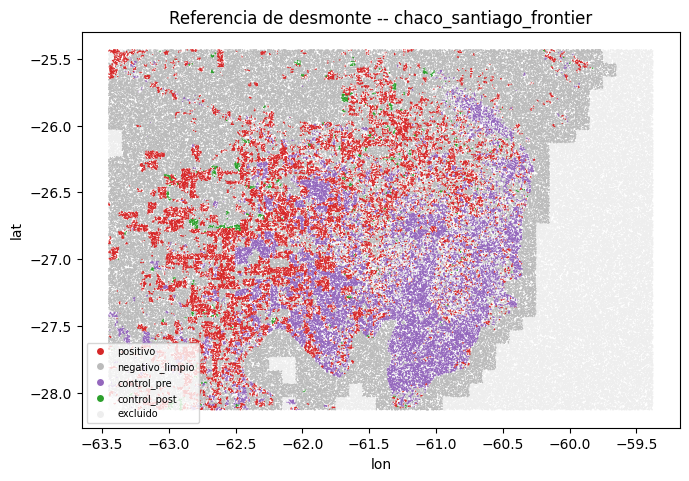

In [14]:
# F1 -- mapa simple de la referencia (no reemplaza al visor interactivo de viz/clusters/,
# solo da una vista rápida acá mismo). Si la zona tiene muchos píxeles, se muestrea.
fig, ax = plt.subplots(figsize=(7, 7))
sample = master_best.sample(min(200_000, len(master_best)), random_state=42)
color_map = {
    "positivo": "#D62728", "negativo_limpio": "#BBBBBB",
    "control_pre": "#9467BD", "control_post": "#2CA02C", "excluido": "#EEEEEE",
}
colors = sample["referencia"].map(color_map)
ax.scatter(sample["longitude"], sample["latitude"], c=colors, s=1, linewidths=0)
ax.set_aspect("equal")
ax.set_title(f"Referencia de desmonte -- {zone}")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=6, label=k)
           for k, c in color_map.items()]
ax.legend(handles=handles, fontsize=7, loc="lower left")
fig.tight_layout()


## 8. Análisis de errores

A qué corresponden los falsos positivos y los falsos negativos de la corrida ganadora, sobre la
regla semántica (`proceso ∈ {deforestacion, degradacion_forestal}` vs. `referencia == positivo`).

In [15]:
sub = master_best[master_best["referencia"].isin(["positivo", "negativo_limpio"])]
yhat = sub["proceso"].isin(ED.DEFOR_PROCESOS)
y = sub["referencia"] == "positivo"

falsos_positivos = sub[(~y) & yhat]
falsos_negativos = sub[y & (~yhat)]

print(f"falsos positivos: {len(falsos_positivos):,} / {len(sub):,}")
print("clusters más frecuentes entre los FP (candidatos a oscilación F<->Sh sin cambio real):")
print(falsos_positivos["cluster"].value_counts().head(10))

print(f"\nfalsos negativos: {len(falsos_negativos):,} / {len(sub):,}")
print("proceso asignado a los FN (¿degradación que no cruzó a deforestación? ¿oscilante?):")
print(falsos_negativos["proceso"].value_counts())

print("\nfrac_ventana de los FN -- ¿son polígonos chicos que no llegaron al umbral tau,")
print("o el cluster realmente no los detecta pese a tener casi todo el pixel desmontado?")
falsos_negativos["frac_ventana"].describe()


falsos positivos: 19,523 / 793,112
clusters más frecuentes entre los FP (candidatos a oscilación F<->Sh sin cambio real):
cluster
35    2512
30    1823
31    1755
92    1460
33    1354
29    1291
36    1203
25    1134
93    1069
47     888
Name: count, dtype: int64

falsos negativos: 106,554 / 793,112
proceso asignado a los FN (¿degradación que no cruzó a deforestación? ¿oscilante?):
proceso
sin_info               104622
expansion_agricola       1201
regeneracion_bosque       499
dinamica_hidrica          186
otro                       45
urbanizacion                1
Name: count, dtype: int64

frac_ventana de los FN -- ¿son polígonos chicos que no llegaron al umbral tau,
o el cluster realmente no los detecta pese a tener casi todo el pixel desmontado?


count   106554.000
mean         0.876
std          0.155
min          0.500
25%          0.756
50%          0.973
75%          1.000
max          1.000
Name: frac_ventana, dtype: float64

## Conclusiones

_(completar tras correr `scripts/datos/build_desmonte_labels.py` + `scripts/validacion/eval_desmonte.py --n-boot 999`
de punta a punta -- las cifras de este notebook alimentan `docs/v2/paper_metodologia.md` §5.8, ver
Fase 6 del plan de validación externa)._